# Hi-C data analysis workshop (part 4: hicstuff)
Aurèle Piazza, Romain Bulteau

09/2026

---



## Overview
In this section, we will use `hicstuff` (and serpentine) to
 - subsample contact matrices
 - compute direct and progressive-binning (serpentine) ratio maps between samples
 - compute and plot distance to contact frequency probability distributions (the $P(s)$)

Supporting material:

 - [`hicstuff` documentation](https://hicstuff.readthedocs.io/en/latest/index.html)
 - [`serpentine` documentation](https://serpentine.readthedocs.io/en/latest/)

## Setup

Since each notebook is in its own environment, we need to install the dependencies and fetch the data we need for the course at the start of each notebook.

You can go to the Table of contents (on the left) and click the 'play' symbol next to the Setup section to run the whole section at once.

### Install & check dependencies

In [1]:
!pip install cooler cooltools hicstuff==3.2.4 serpentine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 17.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.3/109.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.2/876.2 kB 50.4 MB/s eta 0:00:00
  Created wheel for cooltools: filename=cooltools-0.7.1-cp313-cp313-l

In [3]:
import os
import cooler
import numpy as np
import serpentine as sp
import hicstuff.io as hio
import hicstuff.view as hcv
import hicstuff.hicstuff as hcs
import hicstuff.version as hcs_v
import hicstuff.distance_law as hdl
from cooltools.lib.numutils import coarsen
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

# version check
print(f"hicstuff: {hcs_v.__version__}")
print(f"cooler: {cooler.__version__}")
print(f"serpentine: {sp.__version__}")
print(f"numpy: {np.__version__}")

# nb cores available
ncores = 4

hicstuff: 3.2.4
cooler: 0.10.4
serpentine: 0.1.3
numpy: 2.1.3


### Download course data

In [4]:
# path to a folder on your drive where data will be saved
inputdir="hic_data/"
os.makedirs(inputdir, exist_ok=True) # create dir if not exist

# URLs to fetch the data
hicstuff_output_url = "https://sdrive.cnrs.fr/public.php/dav/files/xbqPnPwdEg7WMFd"
cool_url = "https://sdrive.cnrs.fr/public.php/dav/files/HXEWiinMcrPsTJw"

In [5]:
# subfolders with unzipped data (don't modify)
hicstuff_output_folder = f"{inputdir}/AD281_0.02_subsamp/"
cool_folder = f"{inputdir}/cool/"


# download & unzip data if subfolders are missing
if not os.path.isdir(hicstuff_output_folder):
  !wget {hicstuff_output_url}/?accept=zip -O {inputdir}/hcs_data.zip
  !unzip {inputdir}/hcs_data.zip -d {inputdir}

if not os.path.isdir(cool_folder):
  !wget {cool_url}/?accept=zip -O {inputdir}/cool.zip
  !unzip {inputdir}/cool.zip -d {inputdir}



--2026-09-02 12:20:18--  https://sdrive.cnrs.fr/public.php/dav/files/xbqPnPwdEg7WMFd/?accept=zip
Resolving sdrive.cnrs.fr (sdrive.cnrs.fr)... 193.55.86.34
Connecting to sdrive.cnrs.fr (sdrive.cnrs.fr)|193.55.86.34|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘hic_data//hcs_data.zip’

hic_data//hcs_data.     [               <=>  ]  63.85M  12.0MB/s    in 10s     

2026-09-02 12:20:30 (6.17 MB/s) - ‘hic_data//hcs_data.zip’ saved [66952345]

Archive:  hic_data//hcs_data.zip
   creating: hic_data/AD281_0.02_subsamp/
   creating: hic_data/AD281_0.02_subsamp/plots/
 extracting: hic_data/AD281_0.02_subsamp/plots/event_distribution.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/distance_law.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/event_distance.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/frags_hist.pdf  
 extracting: hic_data/AD281_0.02_subsamp/info_contigs.txt  
 extracting: hic_data/AD281_0.02_s

## Sample loading

In [6]:
# path to a folder on your drive where files/plots will be saved
outputdir="outputs/part4/"
os.makedirs(outputdir, exist_ok=True) # create dir if not exist

# path to the workshop cool files
cooldir=f"{cool_folder}"

# list of sample names
samples=[
    "AD281_AD285_AD337_AD363_S288c_DSB_chr3_rDNA_cutsite_q20_v312",
    "AD355_S288c_DSB_chr3_rDNA_cutsite_q20_v312"
]

# color map for plotting
cmap = plt.get_cmap("YlOrBr")
cmap.set_bad('white')

## Comparing Hi-C contact maps

Hi-C ratio maps allow us to compare contact frequency changes between experimental conditions.

We will load two samples from the workshop cool files.
`AD281_...` and `AD355_...` correspond to wild-type and Scc-1 mutant samples 4h after a double-strand break induction in chr5, respectively.

In [7]:
inputA = samples[0] # AD281.. (WT)
inputB = samples[1] # AD355.. (Scc1)

coolA = str(cooldir + inputA + ".mcool::/resolutions/1000")
coolB = str(cooldir + inputB + ".mcool::/resolutions/1000")

# load matrices
matA, fragsA, chromsA = hio.flexible_hic_loader(coolA)
matB, fragsB, chromsB = hio.flexible_hic_loader(coolB)


### Subsampling
To faithfully compare two maps, the total number of contacts should be similar between them.
We subsample the bigger matrix to match the level of the smaller one.

In [8]:
# Compute total contacts (sum of matrix entries)
totalA = matA.data.sum()
totalB = matB.data.sum()

print("Total contacts:")
print(f"\t{inputA}: \t {totalA}")
print(f"\t{inputB}: \t {totalB}")

target = np.min((totalA,totalB)) # set smaller total as target

print(f'\nTarget: \t{target}')

Total contacts:
	AD281_AD285_AD337_AD363_S288c_DSB_chr3_rDNA_cutsite_q20_v312: 	 133323507
	AD355_S288c_DSB_chr3_rDNA_cutsite_q20_v312: 	 28115803

Target: 	28115803


In [9]:
# Subsample to match the target (may take a while)
matA_sub = hcs.subsample_contacts(matA, target) if totalA > target else matA
matB_sub = hcs.subsample_contacts(matB, target) if totalB > target else matB

frags_sub = fragsA # or B

print("Subsampled to", target, "contacts")

Subsampled to 28115803 contacts


In [10]:
# Normalize subsampled matrices
matA_subn = hcs.normalize_sparse(matA_sub, norm='SCN', iterations=40, n_mad=30)
matB_subn = hcs.normalize_sparse(matB_sub, norm='SCN', iterations=40, n_mad=30)

Let's check our two maps

In [11]:
chrs = ["chr5"] # pick a chr to work on

bins  = frags_sub[(frags_sub["chrom"]== chrs[0])].index.values
start = min(bins)
stop  = max(bins)

cA = hcv.sparse_to_dense(matA_subn.tocsr()[start:stop,start:stop].tocoo(), remove_diag=False) # to csr for subsetting, to coo for hcv conversion to_dense for plotting
cB = hcv.sparse_to_dense(matB_subn.tocsr()[start:stop,start:stop].tocoo(), remove_diag=False)



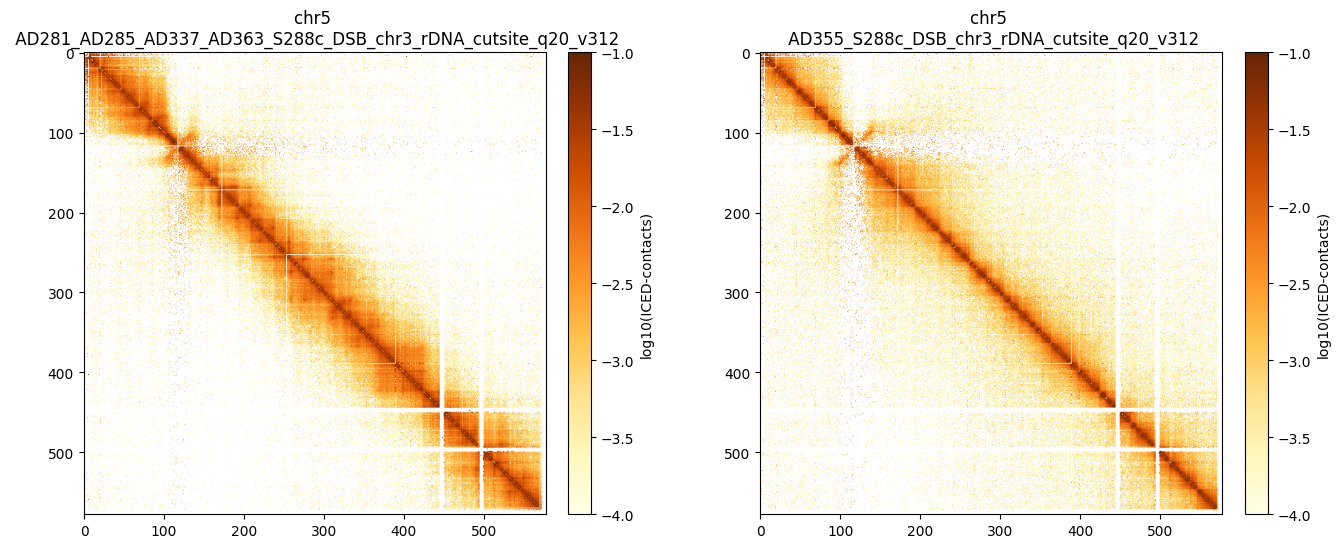

In [12]:
# plot side by side
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1);
im = ax1.imshow(np.log10(cA), cmap=cmap, vmax=-1, vmin=-4)
plt.colorbar(im, fraction=0.046, pad=0.04, label='log10(ICED-contacts)')
ax1.set_title(chrs[0] + " \n " + inputA)

ax2 = fig.add_subplot(1, 2, 2);
im = ax2.imshow(np.log10(cB), cmap=cmap, vmax=-1, vmin=-4)
ax2.set_title(chrs[0] + " \n " + inputB)

plt.colorbar(im, fraction=0.046, pad=0.04, label='log10(ICED-contacts)')

We'll make a function to plot multiple maps side by side for easier handling.

In [13]:
def plot_maps(Mlist,                       # list of matrice to plot
              titlelist=None,              # list of titles for plots
              cmap = cmap,                 # colormap
              legend="Contact frequency",  # name of legend (can be list)
              vmn = None, vmx = None,      # colormap min/max values
              figsize = None               # figure size (auto defined as (n*6, 4))
             ):
    # param handling
    n = len(Mlist)
    titlelist = ["Sample "+str(i+1) for i in range(n)] if titlelist is None else titlelist
    legend = [legend for i in range(n)] if not isinstance(legend, list) else legend
    figsize = (6*n, 4) if figsize is None else figsize

    # plot
    fig = plt.figure(figsize=figsize)
    for i in range(n):
        ax = fig.add_subplot(1,n,i+1)
        im = ax.imshow(Mlist[i], cmap=cmap, vmin=vmn, vmax=vmx)
        ax.set_title(titlelist[i])
        plt.colorbar(im, fraction=0.046, pad=0.04, label=legend[i])
    return fig

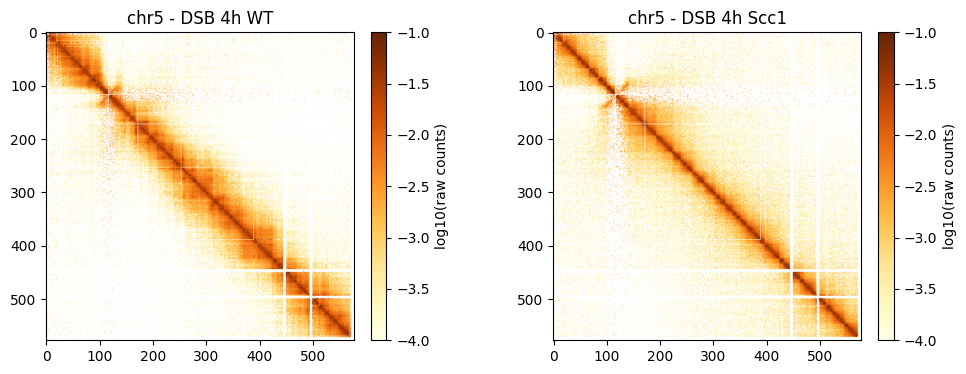

In [14]:
f = plot_maps([np.log10(cA),np.log10(cB)],
              titlelist = [
                  '_'.join(chrs) + " - DSB 4h WT",
                  '_'.join(chrs) + " - DSB 4h Scc1"
              ],
              legend="log10(raw counts)", vmx=-1, vmn=-4)
f.savefig(str(outputdir + inputA + '_' + inputB + '_'.join(chrs) + "_log10_ICED" + ".pdf"), format="pdf", dpi=300)
f.show()

### Making a ratio map of B / A

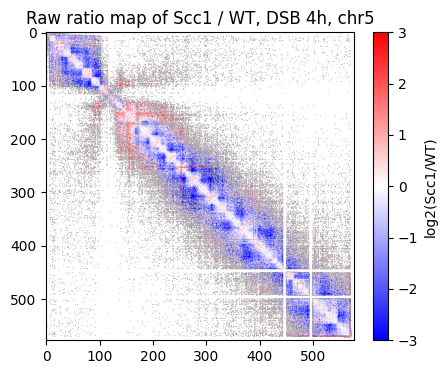

In [15]:
# plot a direct ratiomap

f = plot_maps([np.log2(cB/cA)], cmap='bwr',
              titlelist = ["Raw ratio map of Scc1 / WT, DSB 4h, "+chrs[0]],
             vmx=3, vmn=-3, legend = "log2(Scc1/WT)")

f.show()
f.savefig(str(outputdir + inputB + '_over_' + inputA + '_'.join(chrs) + "_ratiomap" + ".pdf"), format="pdf", dpi=300)

Here, we run into an issue: most of our bins are empty !

Indeed, while the diagonal has may contacts, longer-range interactions, in particular inter-chromosomal, are difficult to assess with a direct ratio map approach.

In [16]:
# count bins with zero in A or B
zerocount = np.sum((cA == 0) | (cB == 0))
# total bins in matrix
nbins = cA.shape[0]**2

print(f'binning:  1kb, {zerocount} empty bins out of {nbins} ({np.round(100*zerocount/nbins, 2)}%)')

binning:  1kb, 249909 empty bins out of 334084 (74.8%)


One solution to avoid this is to increase the bin size to reduce empty bins, at the cost of resolution.

Let's check the same map for a 5kb, 10kb, and 20kb binning.

In [17]:
res = ["5000", "10000", "20000"] # resolutions to explore

cA_lores = [] # to store the matrices
cB_lores = []

for r in res:
    print(f'Processing {int(r)/1000}kb resolution')

    # load matrices
    mA, fA, chA = hio.flexible_hic_loader(str(cooldir + inputA + ".mcool::/resolutions/" + r))
    mB, fB, chB = hio.flexible_hic_loader(str(cooldir + inputB + ".mcool::/resolutions/" + r))

    print('\tsubsampling...')
    # subsample target has not changed since the nb of contacts is the same
    mA_sub = mA if mA.data.sum() == target else hcs.subsample_contacts(mA, target)
    mB_sub = mB if mB.data.sum() == target else hcs.subsample_contacts(mB, target)
    f_sub = fA # or B

    print('\tnormalization...')
    # normalize
    mA_subn = hcs.normalize_sparse(mA_sub, norm='SCN', iterations=40, n_mad=30)
    mB_subn = hcs.normalize_sparse(mB_sub, norm='SCN', iterations=40, n_mad=30)

    print('\tfetching chr of interest...')
    # fetch chr 5
    bins  = f_sub[(f_sub["chrom"]== chrs[0])].index.values
    start = min(bins)
    stop  = max(bins)

    cA_lores.append(hcv.sparse_to_dense(mA_subn.tocsr()[start:stop,start:stop].tocoo(), remove_diag=False))
    cB_lores.append(hcv.sparse_to_dense(mB_subn.tocsr()[start:stop,start:stop].tocoo(), remove_diag=False))

Processing 5.0kb resolution
	subsampling...
	normalization...
	fetching chr of interest...
Processing 10.0kb resolution
	subsampling...
	normalization...
	fetching chr of interest...
Processing 20.0kb resolution
	subsampling...
	normalization...
	fetching chr of interest...


In [18]:
for i,r in enumerate(res):
    # count bins with zero in A or B
    zerocount = np.sum((cA_lores[i] == 0) | (cB_lores[i] == 0))
    # total bins in matrix
    nbins = cA_lores[i].shape[0]**2

    print(f'binning:  {int(r)/1000}kb, {zerocount} empty bins out of {nbins} ({np.round(100*zerocount/nbins, 2)}%)')

binning:  5.0kb, 1824 empty bins out of 13225 (13.79%)
binning:  10.0kb, 26 empty bins out of 3249 (0.8%)
binning:  20.0kb, 0 empty bins out of 784 (0.0%)


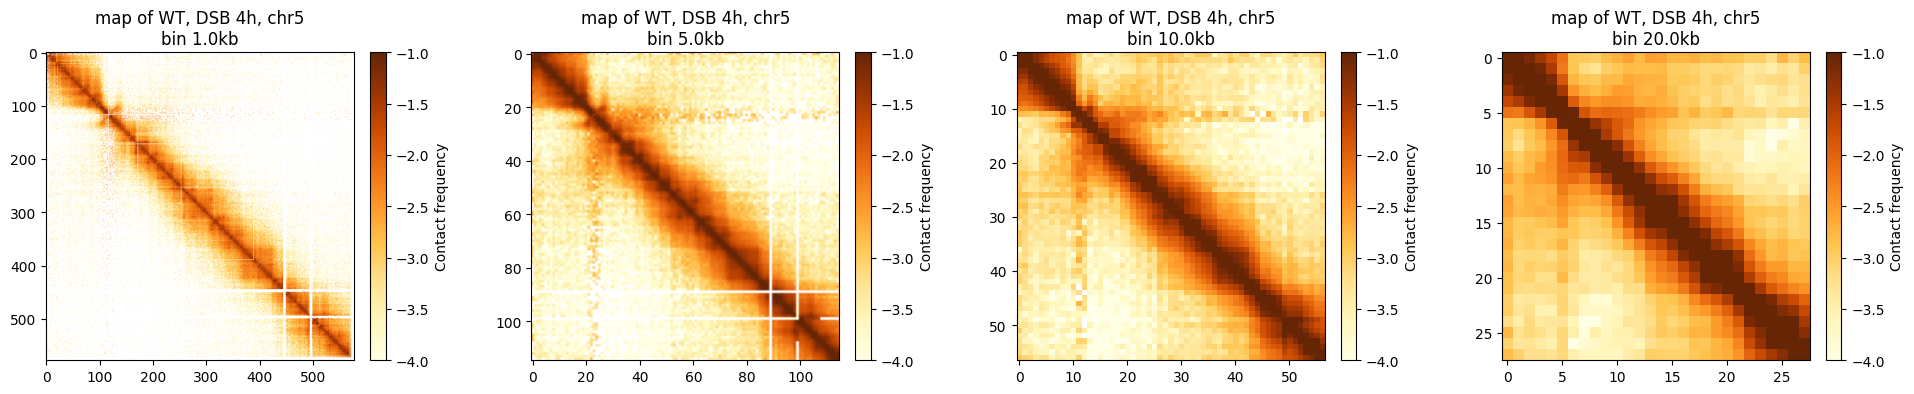

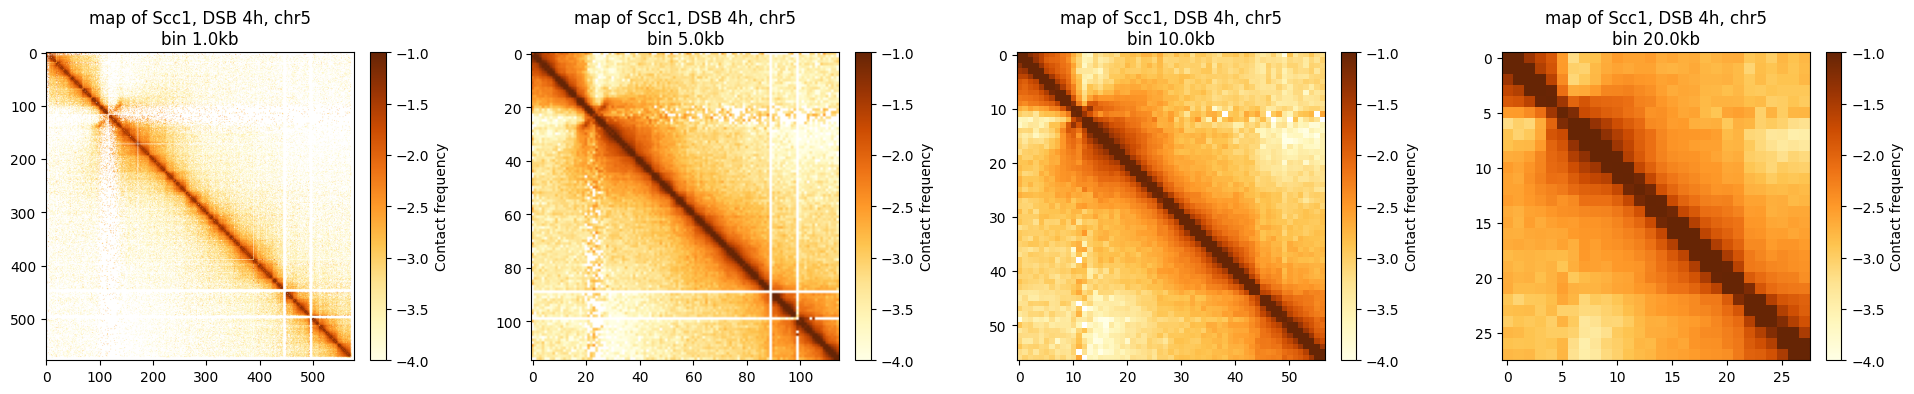

In [19]:
# sample A
f = plot_maps([np.log10(cA)] + [np.log10(cA_lores[i]) for i in range(len(cA_lores)) ], cmap=cmap,
              titlelist = ["map of WT, DSB 4h, "+chrs[0] + f"\nbin {int(r)/1000}kb" for r in ["1000"] + res ],
              vmx=-1, vmn=-4)
f.show()
f.savefig(str(outputdir + inputA + '_'.join(chrs) + "_resolutions_log10_ICED" + ".pdf"), format="pdf", dpi=300)


# sample B
f = plot_maps([np.log10(cB)] + [np.log10(cB_lores[i]) for i in range(len(cB_lores)) ], cmap=cmap,
              titlelist = ["map of Scc1, DSB 4h, "+chrs[0] + f"\nbin {int(r)/1000}kb" for r in ["1000"] + res ],
              vmx=-1, vmn=-4)

f.show()
f.savefig(str(outputdir + inputB + '_'.join(chrs) + "_resolutions_log10_ICED" + ".pdf"), format="pdf", dpi=300)


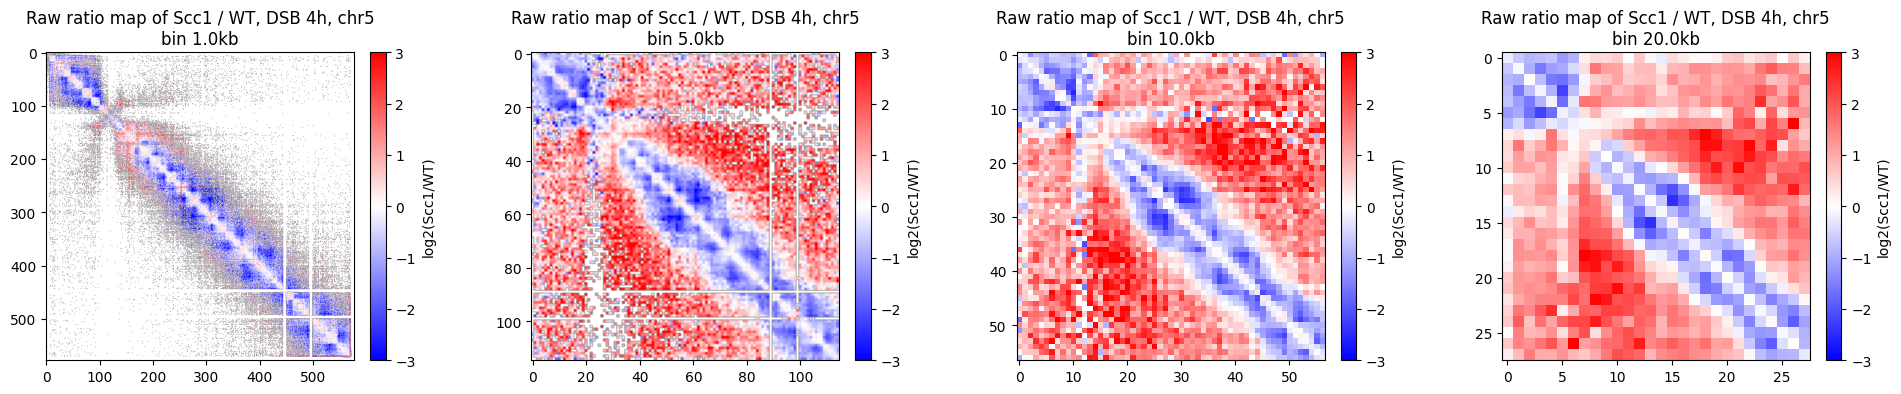

In [20]:
# check ratio maps
f = plot_maps([np.log2(cB/cA)] + [np.log2(cB_lores[i] / cA_lores[i]) for i in range(len(cA_lores)) ], cmap='bwr',
              titlelist = ["Raw ratio map of Scc1 / WT, DSB 4h, "+chrs[0] + f"\nbin {int(r)/1000}kb" for r in ["1000"] + res ],
              vmx=3, vmn=-3, legend = "log2(Scc1/WT)")

f.show()
f.savefig(str(outputdir + inputB + '_over_' + inputA + '_'.join(chrs) + "_resolutions_ratiomap" + ".pdf"), format="pdf", dpi=300)

### Serpentine


To avoid this resolution loss, in particular at close range where coarse binning is detrimental, we will use ***[serpentine](https://serpentine.readthedocs.io/en/latest)***, a progressive binning strategy to group together areas of the matrix with less contacts.

The coverage of our data will, of course, impact how much binning is needed.
When comparing matrices with different coverages, a so-called trending constant therefore needs to be determined, and subtracted from the result.

The serpentine library provides a tool in the form of a mean-difference (MD) plot to dertermine this.
The graph shows that the data has a characteristic noise-to-signal ratio at large coverages that becomes much larger at lower coverages due to sampling noise.

The function `MDbefore()` finds the optimal trend and threshold values, the graph higlights the median and the median absolute deviation (MAD) as red and green lines respectively, plotted as a function of the mean contact number.

trend:	0.10524139015751359
threshold:	49.999999999999986


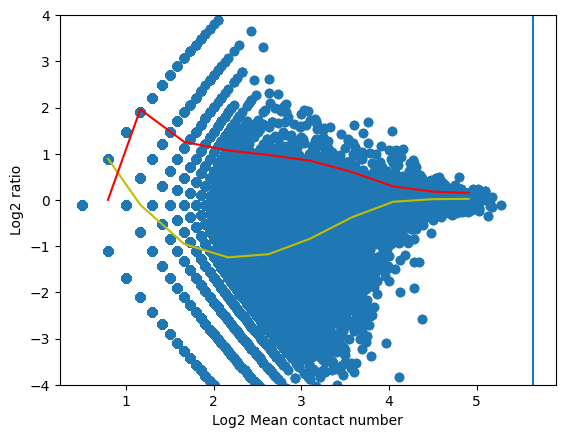

In [21]:
chrs = ["chr5"] # pick a chr to work on

bins  = frags_sub[(frags_sub["chrom"]== chrs[0])].index.values
start = min(bins)
stop  = max(bins)

# fetch raw counts
cAr = hcv.sparse_to_dense(matA_sub.tocsr()[start:stop,start:stop].tocoo(), remove_diag=False)
cBr = hcv.sparse_to_dense(matB_sub.tocsr()[start:stop,start:stop].tocoo(), remove_diag=False)


high = 50 # default 50 or threshold
low  = 5  # default 5 or threshold/5
cycles = 30

plt.figure()
trend, threshold = sp.MDbefore(cAr, cBr, ylim=[-4, 4])
print(f'trend:\t{trend}\nthreshold:\t{threshold}')

Since we already subsampled the full matrices, the trend and thresholds for the selected chromosome detected by the tool above are essentially the defaults.
We can proceed without adjustments.

In [22]:
# compute serpentine binning (may take a while)
sA, sB, sK = sp.serpentin_binning(cAr, cBr, high, low, cycles, parallel=ncores)


Starting 30 binning processes in batches of 4...
0	 Total serpentines: 334084 (100.0 %)
0	 Total serpentines: 334084 (100.0 %)
0	 Total serpentines: 334084 (100.0 %)
0	 Total serpentines: 334084 (100.0 %)
1	 Total serpentines: 224711 (67.26182636702147 %)
1	 Total serpentines: 224614 (67.2327917529723 %)
1	 Total serpentines: 224605 (67.23009781971001 %)
1	 Total serpentines: 224811 (67.29175895882473 %)
2	 Total serpentines: 83476 (24.986530333688535 %)
2	 Total serpentines: 83422 (24.970366734114773 %)
2	 Total serpentines: 83507 (24.995809437147543 %)
2	 Total serpentines: 83304 (24.935046275786927 %)
3	 Total serpentines: 37913 (11.348343530369608 %)
3	 Total serpentines: 37756 (11.301349361238492 %)
3	 Total serpentines: 37825 (11.32200284958274 %)
3	 Total serpentines: 37914 (11.34864285628764 %)
4	 Total serpentines: 23595 (7.062595035978975 %)
4	 Total serpentines: 23680 (7.088037739011746 %)
4	 Total serpentines: 23622 (7.070676835765855 %)
4	 Total serpentines: 23556 (7.05092

(np.float64(-0.036343850198798926), np.float64(49.999999999999986))

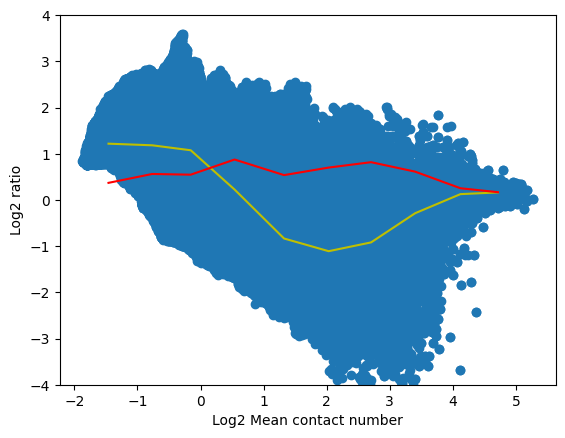

In [23]:
#check binning quality
plt.figure()
sp.MDafter(sA, sB, sK, ylim=[-4, 4])

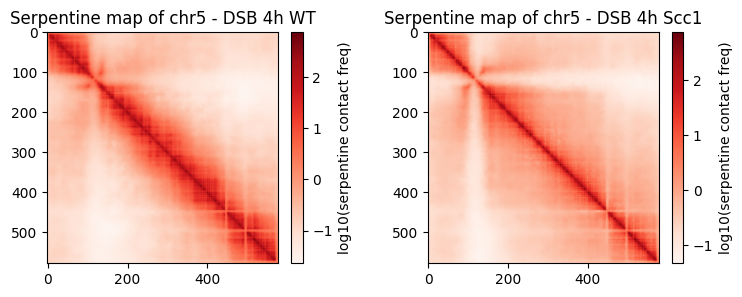

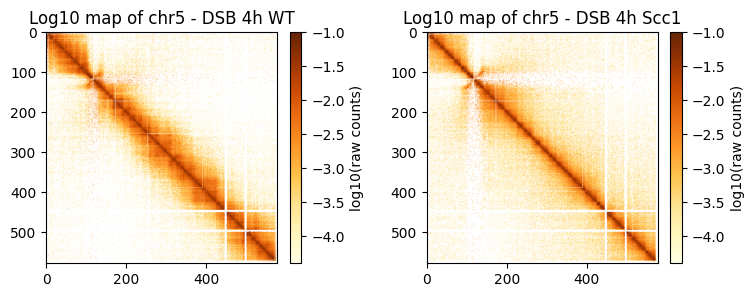

In [24]:
f = plot_maps([np.log10(sA),np.log10(sB)], cmap = "Reds",
              titlelist = [
                  "Serpentine map of "+ '_'.join(chrs) + " - DSB 4h WT",
                  "Serpentine map of "+ '_'.join(chrs) + " - DSB 4h Scc1"
              ],
              #vmn=-1, vmx=-4,
              figsize=(9,3), legend="log10(serpentine contact freq)")
f.savefig(str(outputdir + inputA + '_' + inputB + '_'.join(chrs) + "_serpentine" + ".pdf"), format="pdf", dpi=300)

# show the raw maps below in comparison
f = plot_maps([np.log10(cA),np.log10(cB)],
              titlelist = [
                  "Log10 map of "+ '_'.join(chrs) + " - DSB 4h WT",
                  "Log10 map of "+ '_'.join(chrs) + " - DSB 4h Scc1"
              ],
              vmn=-1, vmx=-4,
              figsize=(9,3), legend="log10(raw counts)")


Notice how the Serpentine maps get "fuzzy" as you move away from the diagonal, as a result of the binning.

This is also clear when looking at the ratio maps:

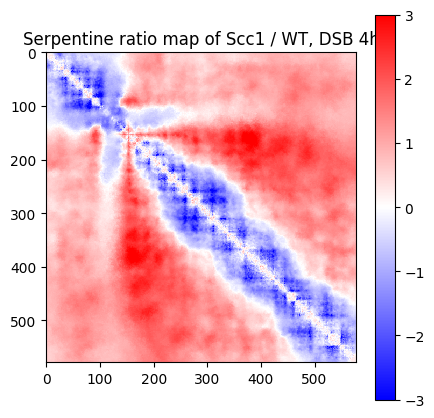

In [25]:
# plot ratio map
f,ax = plt.subplots(figsize=(5,5))

#ax.imshow(sK, cmap= "bwr", vmax=2, vmin=-2)
im = sp.dshow(sK, 0, cmap="bwr", limit = 3)
ax.set(title="Serpentine ratio map of Scc1 / WT, DSB 4h")

f.show()

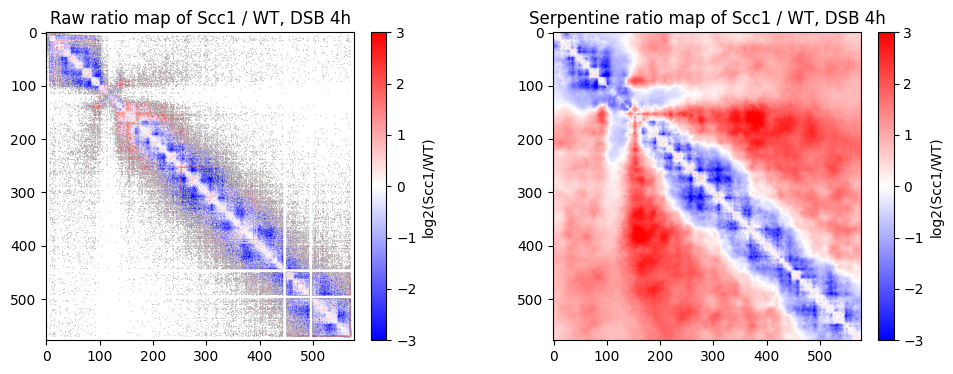

In [26]:
f = plot_maps([np.log2(cB/cA), sK], cmap="bwr",
              titlelist = [
                  "Raw ratio map of Scc1 / WT, DSB 4h",
                  "Serpentine ratio map of Scc1 / WT, DSB 4h"
              ],
              vmx=3, vmn=-3, legend="log2(Scc1/WT)")
f.savefig(str(outputdir + inputA + '_' + inputB + '_'.join(chrs) + "_ratio_map_raw_vs_serpentine" + ".pdf"), format="pdf", dpi=300)

----

<br>

## Distance law computation and plotting

Distance laws are generally computed from `.pairs` files (seen in part 1), as this gives the best genomic coordinate resolution possible (1 base).
This was the case in the `plots/distance_law.pdf` plot generated by the `hicstuff` pipeline.

A uniformly-binned matrix can also be used to approximate distance laws (for distances greater than the bin size).

We will use matrix-inferred distance laws in this part, but see below for code to load, normalize, and plot the distance law from the hicstuff pipeline we ran in part 1.

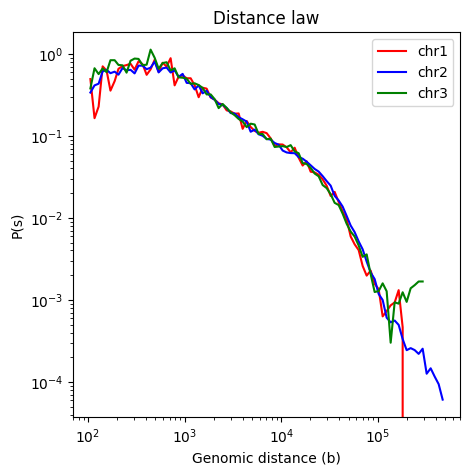

In [28]:
# path to the output from the hicstuff pipeline
hcs_folder=f"{hicstuff_output_folder}"
hcs_sample="AD281_0.02_subsamp_S288c_DSB_chr3_rDNA_parasplit_q20_v324"

# load the distance law file from the sample
xs, ps, names = hdl.import_distance_law(f'{hcs_folder}/distance_law.txt')

# Normalize P(s) to sum to 1
ps = hdl.normalize_distance_law(xs, ps)

# select chrs
chrs=["chr1", "chr2", "chr3"]
cols=['r', 'b','g'] # colors

# create plot area
f, ax = plt.subplots(figsize=(5,5))
for i,ch in enumerate(chrs):
    ch_i = [ i for i,n in enumerate(names) if n[0] == ch ][0]

    # Extract selected chromosome
    chrom_xs, chrom_ps, chrom_name = xs[ch_i], ps[ch_i], names[ch_i]
    # Select interactions between 100b and 500kb
    bp_range = (chrom_xs > 100) & (chrom_xs < 500000)

    # Plot log probability of contact versus log genomic distance
    ax.loglog(chrom_xs[bp_range], chrom_ps[bp_range], c=cols[i])

ax.set(xlabel="Genomic distance (b)", ylabel="P(s)", title="Distance law")
ax.legend(labels=chrs)

f.savefig(str(outputdir+hcs_sample+'_'.join(chrs)+'_Ps_from_pairs.pdf'), dpi=150)
f.show()

<br>

Back to our WT and Scc-1 samples.

Let's extract the submatrices of the chr of interest, compute, ann compare the distance laws.

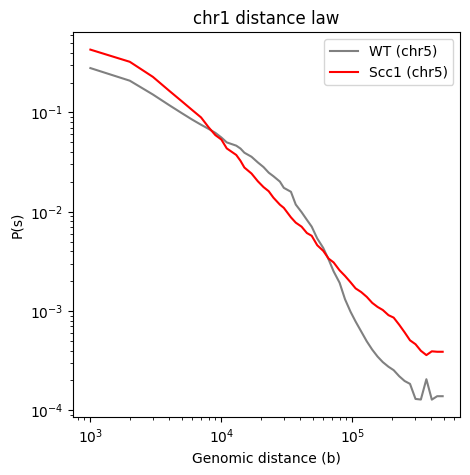

In [29]:
# compute the distance law of selected chr from the matrix
xsA_i, psA = hcs.distance_law_from_mat(cA)
xsB_i, psB = hcs.distance_law_from_mat(cB)

# 1 bin = 1 kb, so adjust xs to genomic coordinates
xsA = xsA_i*1000
xsB = xsB_i*1000

# Normalize P(s) to sum to 1
psA = hdl.normalize_distance_law([xsA], [psA])[0]
psB = hdl.normalize_distance_law([xsB], [psB])[0]



# Select interactions between 100b and 500kb
rgA = (xsA > 100) & (xsA < 500000)
rgB = (xsB > 100) & (xsB < 500000)

# Plot log probability of contact versus log genomic distance
f, ax = plt.subplots(figsize=(5,5))
ax.loglog(xsA[rgA], psA[rgA], c='grey')
ax.loglog(xsB[rgB], psB[rgB], c='red')
ax.set(xlabel="Genomic distance (b)", ylabel="P(s)", title=chrs[0] +  " distance law")
ax.legend(labels=["WT (chr5)", "Scc1 (chr5)"])

f.savefig(str(outputdir+'_'.join([inputA,inputB,''])+'_'.join(chrs)+'_Ps_from_mat_comp.pdf'), dpi=150)
f.show()

We can also compute the slope of the distance laws to make some effects even clearer.

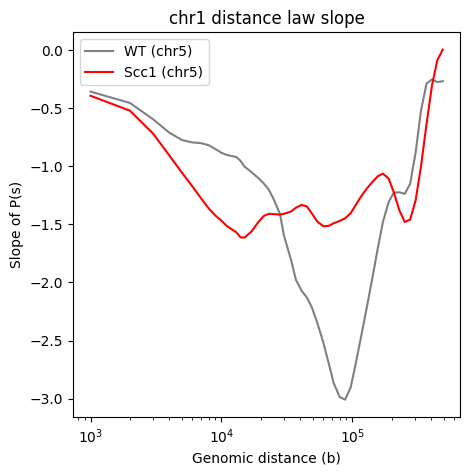

In [30]:
spsA = hdl.slope_distance_law([xsA], [psA])[0]
spsB = hdl.slope_distance_law([xsB], [psB])[0]

# Plot log slope of probability of contact versus log genomic distance
f, ax = plt.subplots(figsize=(5,5))
ax.plot(xsA[rgA], spsA[rgA[1:]], c='grey')
ax.plot(xsB[rgB], spsB[rgB[1:]], c='red')
ax.set_xscale("log", base=10);
ax.set(xlabel="Genomic distance (b)", ylabel="Slope of P(s)", title=chrs[0] +  " distance law slope")
ax.legend(labels=["WT (chr5)", "Scc1 (chr5)"])

f.savefig(str(outputdir+'_'.join([inputA,inputB,''])+'_'.join(chrs)+'_Ps_from_mat_comp.pdf'), dpi=150)
f.show()

We can also work on an averaged law across chromosomes per sample.

In [31]:
# compute the distance law of selected chr from the matrix
chrs = chromsA['contig'][:-2].values # without mitochondrial & 2_micron
print(chrs)

xsA = []
xsB = []
psA = []
psB = []


for ch in chrs:
    bins  = frags_sub[(frags_sub["chrom"]== ch)].index.values
    start = min(bins)
    stop  = max(bins)

    mA = matA_sub.tocsr()[start:stop,start:stop].tocoo()
    mB = matB_sub.tocsr()[start:stop,start:stop].tocoo()
    xsA_i, psA_i = hcs.distance_law_from_mat(mA)
    xsB_i, psB_i = hcs.distance_law_from_mat(mB)

    psA.append(psA_i)
    psB.append(psB_i)
    # 1 bin = 1 kb, so adjust xs to genomic coordinates
    xsA.append(xsA_i * 1000)
    xsB.append(xsB_i * 1000)

# Normalize P(s) to sum to 1
psA = hdl.normalize_distance_law(xsA, psA)
psB = hdl.normalize_distance_law(xsB, psB)

# compute average
avg_xsA, avg_psA = hdl.average_distance_law(xsA, psA, 500000)
avg_xsB, avg_psB = hdl.average_distance_law(xsB, psB, 500000)

# compute average slope
avg_spsA = hdl.slope_distance_law([avg_xsA], [avg_psA])[0]
avg_spsB = hdl.slope_distance_law([avg_xsB], [avg_psB])[0]

# compute all slopes
spsA = hdl.slope_distance_law(xsA, psA)
spsB = hdl.slope_distance_law(xsB, psB)

['chr1' 'chr2' 'chr3' 'chr4' 'chr5' 'chr6' 'chr7' 'chr8' 'chr9' 'chr10'
 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16']


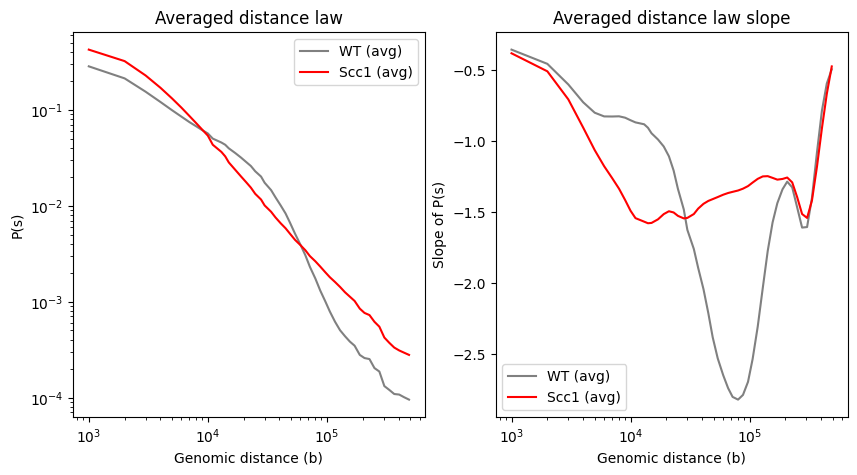

In [32]:
# Select interactions between 100b and 500kb
rgA = (avg_xsA > 100) & (avg_xsA < 500000)
rgB = (avg_xsB > 100) & (avg_xsB < 500000)

# Plot log probability of contact versus log genomic distance
f, (ax1,ax2) = plt.subplots(figsize=(10,5), ncols=2)
ax1.loglog(avg_xsA[rgA], avg_psA[rgA], c='grey')
ax1.loglog(avg_xsB[rgB], avg_psB[rgB], c='red')
ax1.set(xlabel="Genomic distance (b)", ylabel="P(s)", title="Averaged distance law")
ax1.legend(labels=["WT (avg)", "Scc1 (avg)"])

# Plot slope
ax2.plot(avg_xsA[rgA], avg_spsA[rgA[1:]], c='grey')
ax2.plot(avg_xsA[rgB], avg_spsB[rgB[1:]], c='red')
ax2.set_xscale("log", base=10);
ax2.set(xlabel="Genomic distance (b)", ylabel="Slope of P(s)", title="Averaged distance law slope")
ax2.legend(labels=["WT (avg)", "Scc1 (avg)"])

f.savefig(str(outputdir+'_'.join([inputA,inputB,''])+'_avg_Ps_from_mat_comp.pdf'), dpi=150)
f.show()

We can also look at the details per chromosome.

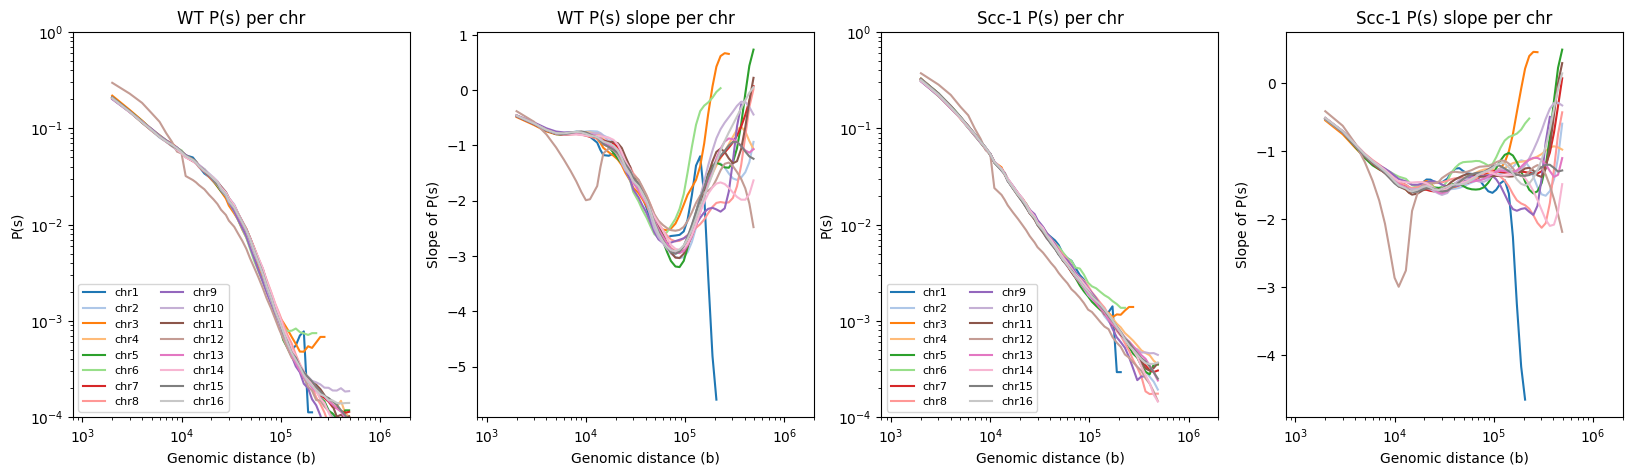

In [33]:
chr_cmap = plt.colormaps.get_cmap('tab20')

f = plt.figure(figsize=(20,5))

ax1,ax2,ax3,ax4 = [f.add_subplot(1,4,i+1) for i in range(4)]

for i, ch in enumerate(chrs):
    # Select interactions between 100b and 500kb
    rgA = (xsA[i] > 1000) & (xsA[i] < 500000)
    rgB = (xsB[i] > 1000) & (xsB[i] < 500000)

    # wt
    ax1.loglog(xsA[i][rgA], psA[i][rgA], c=chr_cmap(i))
    ax2.plot(xsA[i][rgA], spsA[i][rgA[1:]], c=chr_cmap(i))
    ax2.set_xscale("log", base=10);

    # scc1
    ax3.loglog(xsB[i][rgA], psB[i][rgA], c=chr_cmap(i))
    ax4.plot(xsB[i][rgA], spsB[i][rgA[1:]], c=chr_cmap(i))
    ax4.set_xscale("log", base=10);


ax1.set(xlabel="Genomic distance (b)", ylabel="P(s)", title="WT P(s) per chr", xlim=(800,2e6), ylim=(1e-4,1))
ax3.set(xlabel="Genomic distance (b)", ylabel="P(s)", title="Scc-1 P(s) per chr", xlim=(800,2e6), ylim=(1e-4,1))

ax2.set(xlabel="Genomic distance (b)", ylabel="Slope of P(s)", title="WT P(s) slope per chr", xlim=(800,2e6))
ax4.set(xlabel="Genomic distance (b)", ylabel="Slope of P(s)", title="Scc-1 P(s) slope per chr", xlim=(800,2e6))

ax1.legend(labels=chrs, ncols=2, loc='lower left', fontsize = 8)
ax3.legend(labels=chrs, ncols=2, loc='lower left', fontsize = 8)

f.show()
f.savefig(str(outputdir+'_'.join([inputA,inputB,''])+'all_chrs_Ps_slope_from_mat_comp.pdf'), dpi=150)